In [14]:
import string

import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy import stats
from pathlib import Path
from itertools import combinations
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal, shapiro, f_oneway, ttest_rel
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## Data Preprocessing

In [15]:
df_base = pd.read_csv('./data/Attack-C-Results.csv')
df_base.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,ADV_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss
0,2V,True,False,0.007276,0.008945,NaN,NaN,NaN,NaN
1,2V,True,False,0.007288,0.008849,NaN,NaN,NaN,NaN
2,2V,True,False,0.007914,0.009782,NaN,NaN,NaN,NaN
3,2V,True,False,0.008287,0.010235,NaN,NaN,NaN,NaN
4,2V,True,False,0.007602,0.008807,NaN,NaN,NaN,NaN


In [16]:
df_test = df_base.loc[
    (df_base['image_attack'] == True) &
    (df_base['sketch_attack'] == False)
].copy().reset_index(drop=True)

df_test['ADV_IM_Abs_Increase'] = (
    df_test['ADV_IM_Loss'] - df_test['Clean_IM_Loss']
)

df_test['ADV_IM_Rel_Increase'] = (
    df_test['ADV_IM_Abs_Increase'] / df_test['Clean_IM_Loss'] * 100
)

df_test

,model,image_attack,sketch_attack,Clean_IM_Loss,ADV_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss,ADV_IM_Abs_Increase,ADV_IM_Rel_Increase
0,2V,True,False,0.007276,0.008945,NaN,NaN,NaN,NaN,0.001670,22.949004
1,2V,True,False,0.007288,0.008849,NaN,NaN,NaN,NaN,0.001561,21.418736
2,2V,True,False,0.007914,0.009782,NaN,NaN,NaN,NaN,0.001868,23.608350
3,2V,True,False,0.008287,0.010235,NaN,NaN,NaN,NaN,0.001948,23.503439
4,2V,True,False,0.007602,0.008807,NaN,NaN,NaN,NaN,0.001205,15.844884
5,2V,True,False,0.007812,0.009412,NaN,NaN,NaN,NaN,0.001599,20.471458
6,2V,True,False,0.007724,0.009624,NaN,NaN,NaN,NaN,0.001900,24.600686
7,2V,True,False,0.008155,0.010067,NaN,NaN,NaN,NaN,0.001913,23.453788
8,2V,True,False,0.008127,0.009205,NaN,NaN,NaN,NaN,0.001077,13.255655
9,2V,True,False,0.007930,0.009653,NaN,NaN,NaN,NaN,0.001722,21.720899


In [17]:
df_mean = (
    df_test
        .groupby(['model', 'image_attack', 'sketch_attack'], as_index=False)[['Clean_IM_Loss', 'ADV_IM_Loss', 'ADV_IM_Abs_Increase', 'ADV_IM_Rel_Increase']]
        .mean()
        .round(3)
        .reset_index()
)

df_mean

,index,model,image_attack,sketch_attack,Clean_IM_Loss,ADV_IM_Loss,ADV_IM_Abs_Increase,ADV_IM_Rel_Increase
0,0,2V,True,False,0.008,0.009,0.002,21.083


## Plots

In [18]:
model_order = ['2V']

model_color_map = {
    '2V': 'tab:orange',
}

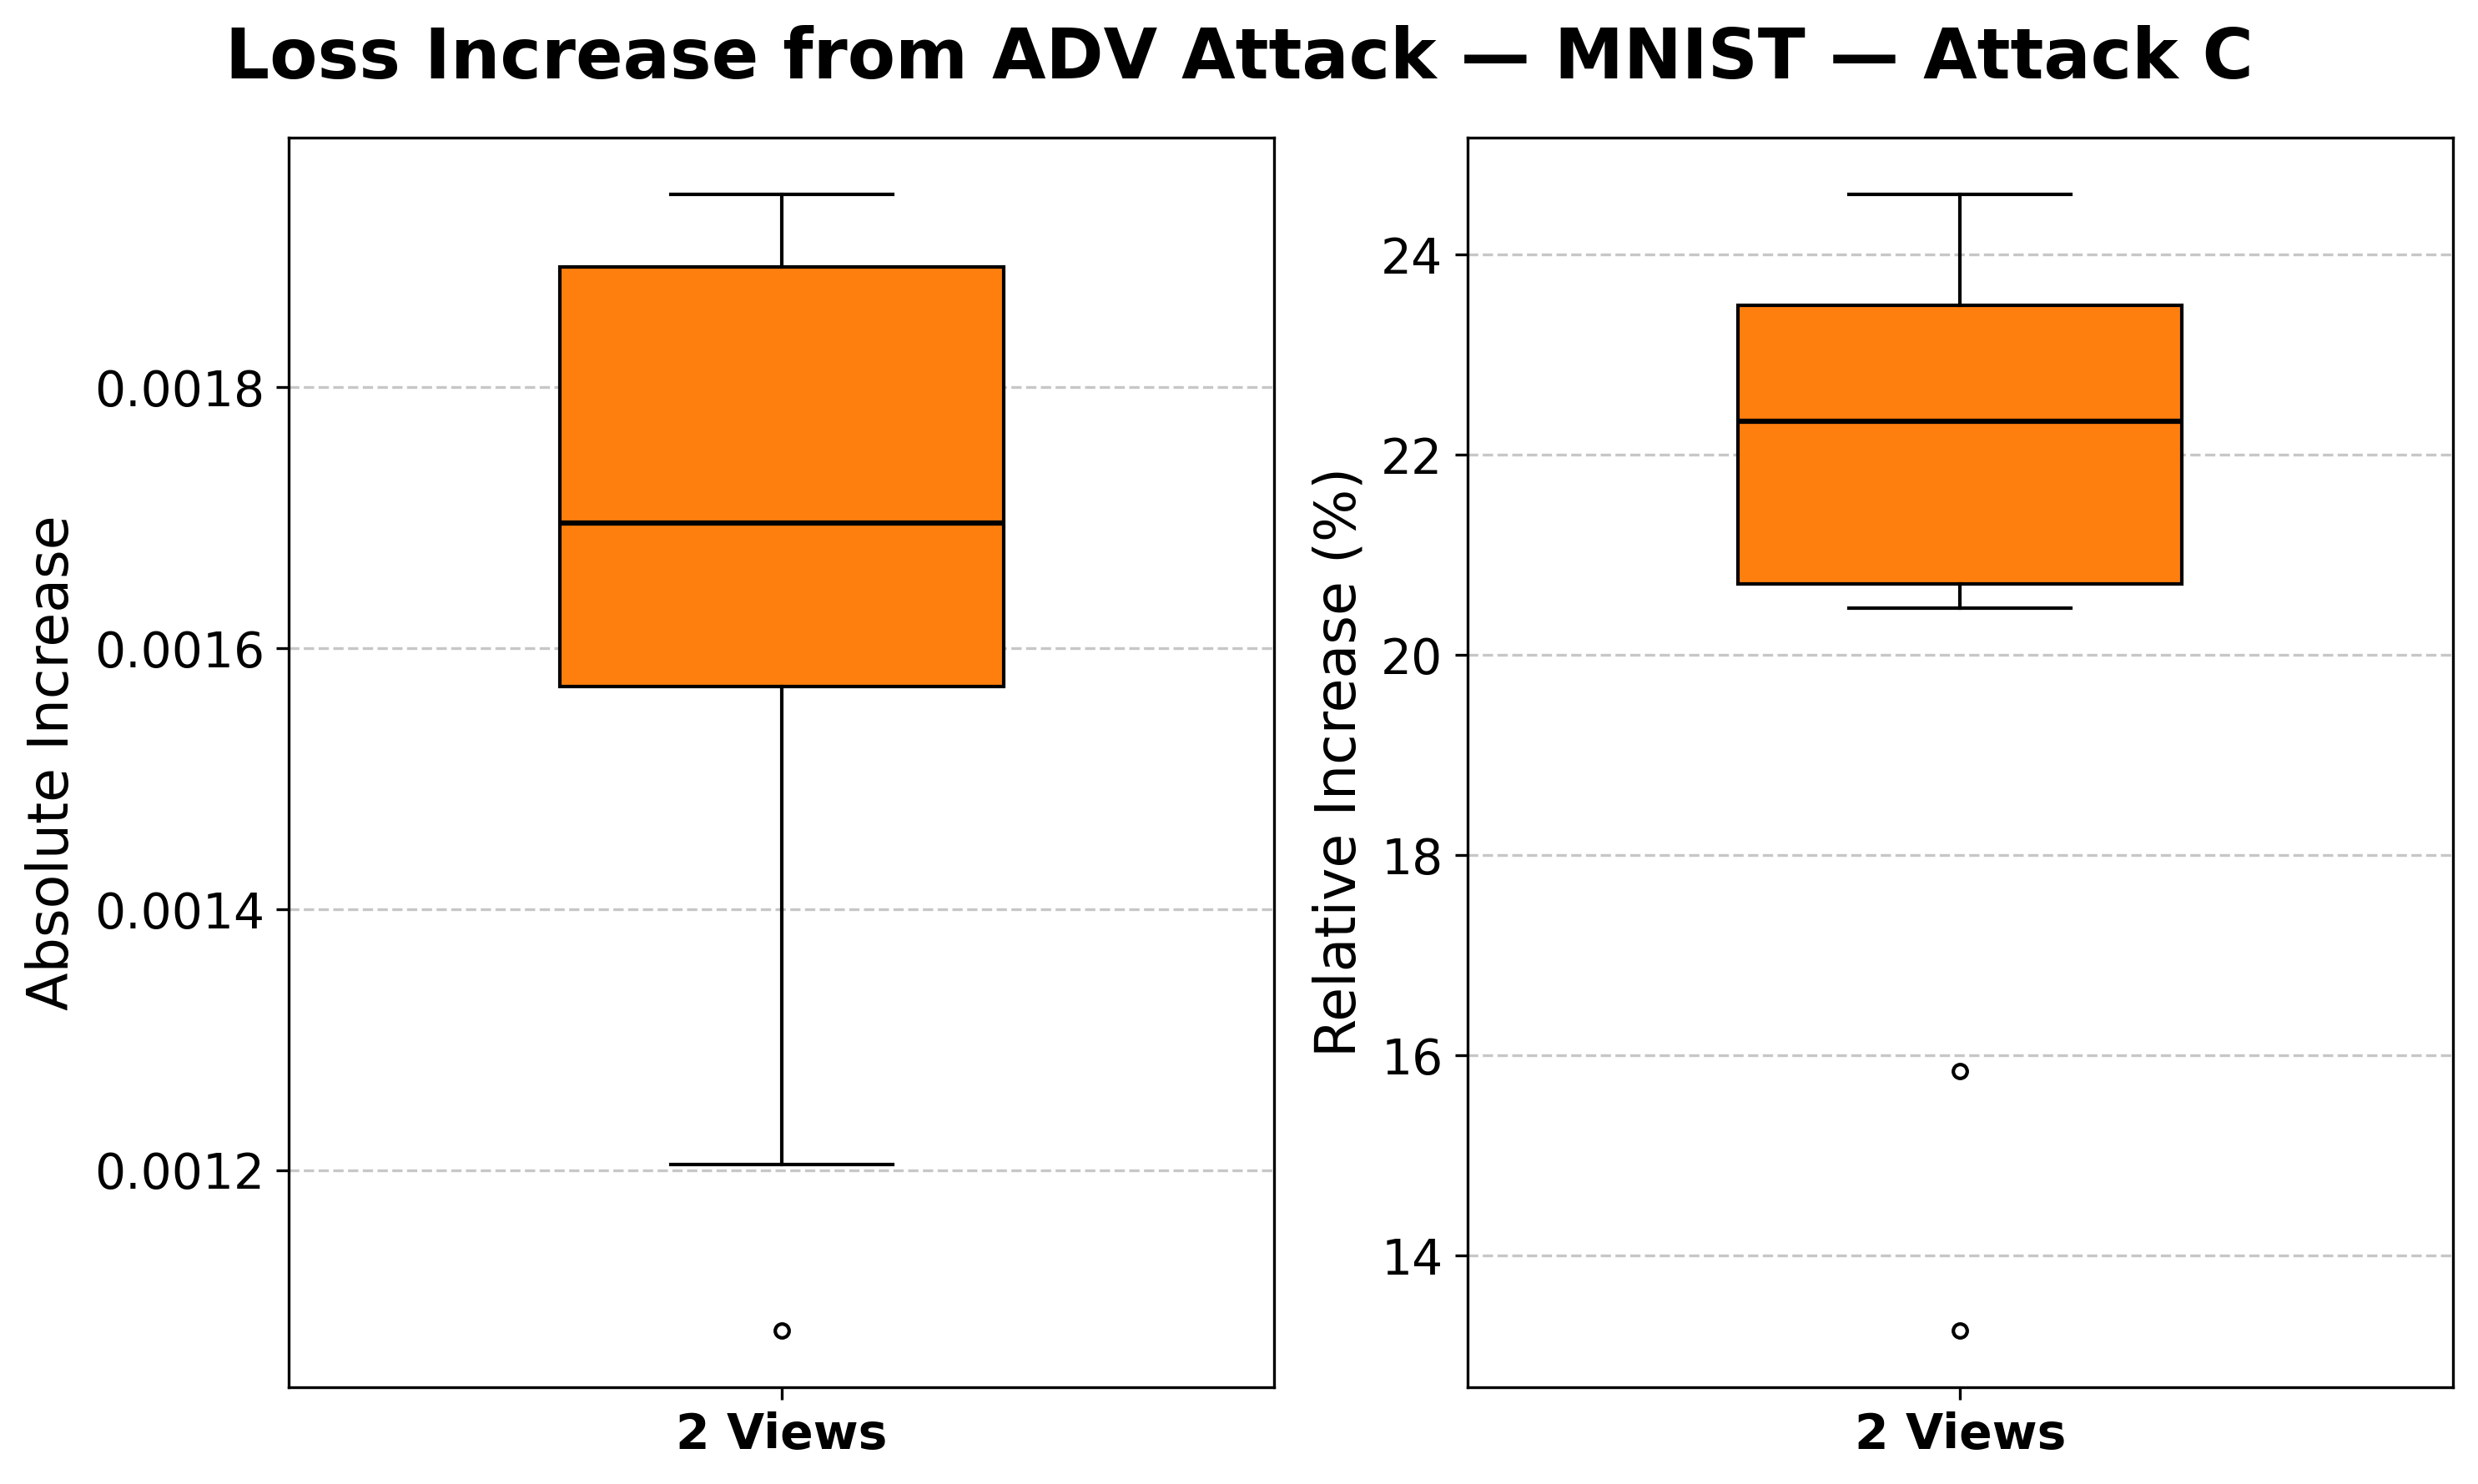

In [19]:
model_label_map = {
    '1V': '1 View',
    '2V': '2 Views',
}

fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=300)

plot_specs = [
    (
        'ADV_IM_Abs_Increase',
        'Absolute Increase',
        'Absolute Image Loss Increase',
    ),
    (
        'ADV_IM_Rel_Increase',
        'Relative Increase (%)',
        'Relative Image Loss Increase',
    ),
]

model_positions = np.arange(len(model_order))

for ax, (col, ylabel, title) in zip(axes, plot_specs):
    values = [
        df_test.loc[df_test['model'].eq(model), col].dropna().to_numpy()
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        positions=model_positions,
        widths=0.45,
        patch_artist=True,
        showfliers=True,
    )

    for patch, model in zip(box['boxes'], model_order):
        patch.set_facecolor(model_color_map[model])
        patch.set_edgecolor('black')

    for median in box['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in box['whiskers']:
        whisker.set_color('black')

    for cap in box['caps']:
        cap.set_color('black')

    for flier in box['fliers']:
        flier.set_marker('o')
        flier.set_markerfacecolor('white')
        flier.set_markeredgecolor('black')
        flier.set_markersize(4)

    ax.set_ylabel(ylabel, fontsize=16)

    ax.set_xticks(model_positions)
    ax.set_xticklabels(
        [model_label_map.get(model, model) for model in model_order],
        fontsize=14,
        fontweight='bold'
    )

    ax.tick_params(axis='y', labelsize=14)

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle('Loss Increase from ADV Attack — MNIST — Attack C', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./img/attack-C-image-loss-increases-boxplots.png', bbox_inches='tight')
plt.show()

## Statistical Tests - Attacks

In [20]:
loss_cols = [
    'Clean_IM_Loss',
    'ADV_IM_Loss',
]

In [21]:
pairwise_results = []

for col1, col2 in combinations(loss_cols, 2):
    paired_data = df_test[[col1, col2]].dropna()

    t_stat, p_value = ttest_rel(
        paired_data[col1],
        paired_data[col2],
    )

    pairwise_results.append({
        'test': 'Paired t-test',
        'comparison': f'{col1} vs {col2}',
        'n': len(paired_data),
        't-statistic': t_stat,
        'p-value': p_value,
        'significant': p_value < 0.05,
    })

ttest_results = pd.DataFrame(pairwise_results)

ttest_results

,test,comparison,n,t-statistic,p-value,significant
0,Paired t-test,Clean_IM_Loss vs ADV_IM_Loss,10,-17.350431,3.167598e-08,True
